In [44]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, TimeSeriesSplit, GridSearchCV, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression, LinearRegression, Lasso, Ridge
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, mean_squared_error, r2_score, mean_absolute_error
DIR = os.path.join(os.getcwd(), "data")

In [38]:
data = {}
for filename in os.listdir(DIR):
    if filename.endswith("_csv_CLEAN.csv"):
        filepath = os.path.join(DIR, f"{filename}")
        response = pd.read_csv(filepath, index_col="Date", parse_dates=True)
        data[filename] = response

        
FEATURE_COLS = [
    'rsi_14', "return_1day", "return_5day", "return_10day", "return_20day", "sma_5", "sma_10", 
    "close_ratio_amv_10", "sma_20", "close_ratio_amv_20", 
    "close_ratio_amv_5", 'macd_line', 'bb_width', 'bb_pct_b', 
    'volatility_10_day', 'volatility_20_day', 
    'volume_1day', 'volume_20_sma', 'volume_normalize_ratio',
]

# for stock, dataframe in data.items():
    # print(stock)
    # print(dataframe.head(5))


#VFV Example
vfv_df = data["VFV_TO_csv_CLEAN.csv"]
vfv_df = vfv_df.dropna(subset=["future_return"])
X = vfv_df[FEATURE_COLS]
y_logistical_reg = vfv_df["target"]
y_linear_reg = vfv_df["future_return"]

#Creating the train and test
X_train, X_test, y_train_log, y_test_log, y_train_lin, y_test_lin = train_test_split(
    X, 
    y_logistical_reg, 
    y_linear_reg, 
    test_size=0.2, 
    shuffle=False 
)


In [39]:

preprocessor = ColumnTransformer(
    transformers=[
        ("num_cleaner", StandardScaler(), FEATURE_COLS)
    ]
)
#Pipeline for Direction (1 or 0)
log_pipeline = Pipeline([
    ("cleaning_steps", preprocessor),
    ("logistic_model", LogisticRegression())
])
#Pipeline for Predicated Values 
lin_pipeline = Pipeline([
    ("cleaning_steps", preprocessor),
    ("linear_model", LinearRegression())
])

print("Training Logistic Model")
log_pipeline.fit(X_train, y_train_log)

print("Training Linear Model")
lin_pipeline.fit(X_train, y_train_lin)


Training Logistic Model
Training Linear Model


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('cleaning_steps', ...), ('linear_model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num_cleaner', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers

In [ ]:
from sklearn.metrics import accuracy_score, mean_squared_error, r2_score

#Accuracy for target
log_predictions = log_pipeline.predict(X_test)
log_accuracy = accuracy_score(y_test_log, log_predictions)
print("\n--- Logistic Regression Results ---")
print(f"Accuracy: {log_accuracy * 100:.2f}%")

#Accuracy for future_return
lin_predictions = lin_pipeline.predict(X_test)
lin_mse = mean_squared_error(y_test_lin, lin_predictions)
lin_r2 = r2_score(y_test_lin, lin_predictions)
print("\n--- Linear Regression Results ---")
print(f"Mean Squared Error: {lin_mse:.6f}")
print(f"R-Squared (R2): {lin_r2:.4f}")


--- Logistic Regression Results ---
Accuracy: 60.98%

--- Linear Regression Results ---
Mean Squared Error: 0.001014 (Lower is better)
R-Squared (R2): -0.9640 (1.0 is perfect)


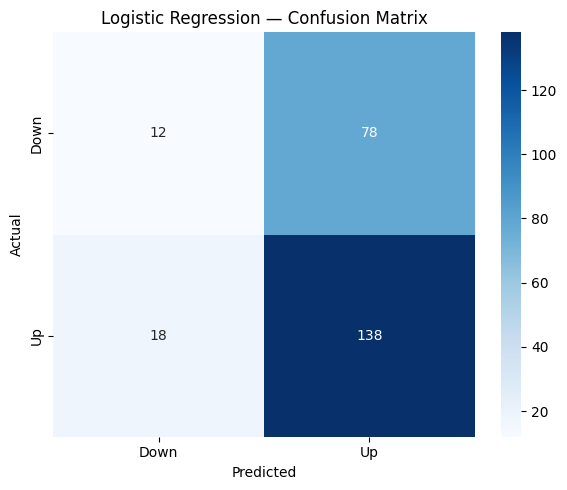

In [43]:
# Confusion matrix
cm = confusion_matrix(y_test_log, log_predictions)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
            xticklabels=["Down", "Up"], yticklabels=["Down", "Up"])
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
ax.set_title("Logistic Regression — Confusion Matrix")
plt.tight_layout()
plt.show()

In [ ]:
#Implementing LASSO and RIDGE to find best parameters to improve accuracy